<a href="https://colab.research.google.com/github/Ashi743/PYTORCH-DEEP-LEARNING/blob/main/ANN_OPTUNA_MLFLOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#!pip install mlflow optuna dagshub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 12.8 MB/s eta 0:00:00


**PYTORCH X OPTUNA X MLFLOW**

**REQUIRED LIBRARIES**

In [19]:
import pandas as pd
import os
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import kagglehub
from kagglehub import KaggleDatasetAdapter
import mlflow
import mlflow.pytorch


**KAGGLE IMPORT OF DATASET**

In [20]:
## Download latest version
# Set the path to the file you'd like to load
file_path = ""

path = kagglehub.dataset_download("xiaoqingjiang/fashionmnist")
# List contents of the directory to find the CSV file
files_in_path = os.listdir(path)

## Load the latest version
import pandas as pd
import os

csv_files= []
for file in files_in_path:
    if file.endswith('.csv'):
        csv_files.append(file)

df_test= pd.read_csv(os.path.join(path, csv_files[0]))
df_train= pd.read_csv(os.path.join(path, csv_files[1]))

## CUDA- GPU usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## set random seed for reproducibility
torch.manual_seed(42)





Using Colab cache for faster access to the 'fashionmnist' dataset.


**A WALKAWAY OF THE FASHIONMNIST DATASET**

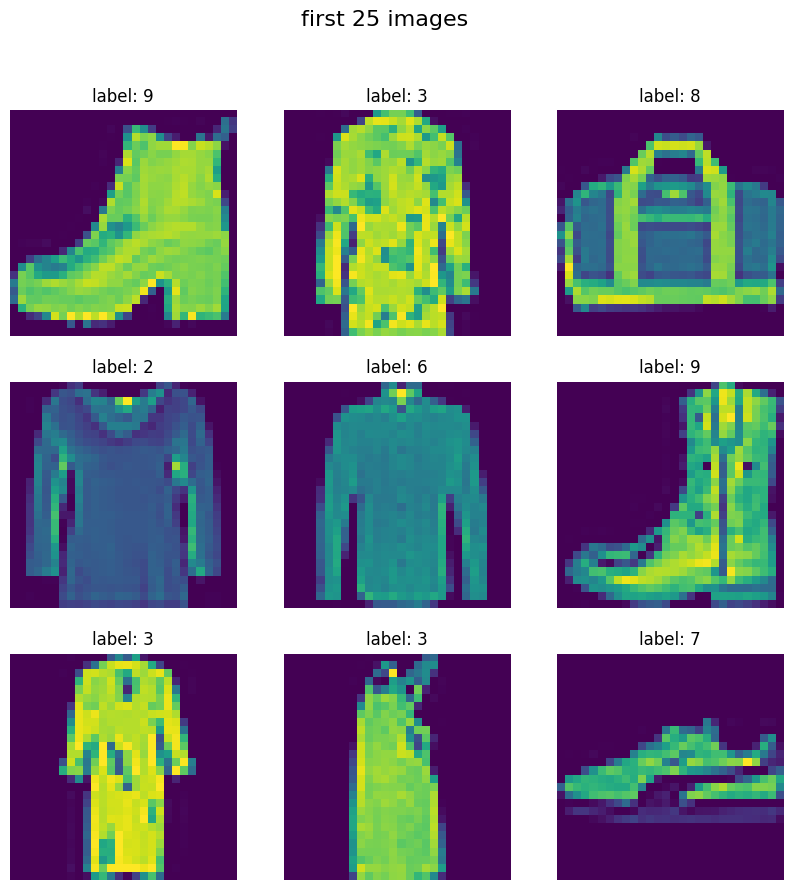

In [21]:
#sample dataset
df_10k= df_train.sample(10000)

#to create 3X3 grid of data
fig, ax =plt.subplots(3,3, figsize=(10,10))
fig.suptitle("first 25 images", fontsize= 16)
for i, ax in enumerate(ax.flat):
    ax.imshow(df_10k.iloc[i,1:].values.reshape(28,28))
    ax.axis("off")
    ax.set_title(f"label: {df_10k.iloc[i,0]}")
plt.tight_layout
plt.show()

**X, y DISTRIBUTION**

In [22]:
X= df_train.iloc[:,1:].values
y= df_train.iloc[:,0].values

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#standard scaler
"""from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)"""

#minmaxscaler
from sklearn.preprocessing import MinMaxScaler
scaler= MinMaxScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

#labelencoder - NOT REQUIRED HERE


#to tensor
X_train_tensor= torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor= torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor= torch.tensor(y_train, dtype=torch.long)
y_test_tensor= torch.tensor(y_test, dtype=torch.long)

**Custom dataset class** -  to load data and extract data

In [23]:
#create custom dataset
class custom_dataset(Dataset):
  def __init__(self, features, labels):
    self.features= features
    self.labels= labels
  def __len__(self):
    return len(self.features)
  def __getitem__(self, idx):
    return self.features[idx], self.labels[idx]

**DYNAMIC nn MODEL**

In [24]:
class nn_model(nn.Module):
  def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layers, dropout_rate):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):

      layers.append(nn.Linear(input_dim, neurons_per_layers))
      layers.append(nn.BatchNorm1d(neurons_per_layers))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(dropout_rate))

      input_dim =neurons_per_layers

    layers.append(nn.Linear(neurons_per_layers, output_dim))

    self.model= nn.Sequential(*layers)

  def forward(self, features):
    return self.model(features)

**OPTUNA HYPERPARAMETER SETUP**

  - objective(inheriting trial) - to setup tunable  hyperparams
  - create study to run objective created

In [25]:
# objective function
def objective(trial):

  with mlflow.start_run():

    ### next hyperparameter values from search space

      ## hyperparams for model
    num_hidden_layers= trial.suggest_int("num_hidden_layers", 1,5)
    neurons_per_layers= trial.suggest_int("neurons_per_layers", 8, 128, step= 8)
    dropout_rate= trial.suggest_float("dropout_rate", 0.1, 0.5)

      ## hyperparams for params
    epochs= trial.suggest_int("epochs", 10, 50, step= 10)
    learning_rate= trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    lambda1= trial.suggest_float("lambda1", 1e-5, 1e-1, log=True)

      ## hyperparams for dataset and dataloader
    batch_size= trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    #dataset
    train_dataset= custom_dataset(X_train_tensor, y_train_tensor)
    test_dataset= custom_dataset(X_test_tensor, y_test_tensor)
    #dataloader
    train_dataloader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    test_dataloader= DataLoader(test_dataset, batch_size=batch_size, shuffle=False ,pin_memory=True) #to calculate accuracy

      ## hyperparams for optimizer
    optimizers= trial.suggest_categorical("optimizers", ["Adam", "SGD", "RMSprop"])

    # Log hyperparameters to MLflow
    mlflow.log_params(trial.params)

    #parameters

    input_dim = X_train_scaled.shape[1]
    output_dim = 10

    #model initailize
    model = nn_model(input_dim, output_dim, num_hidden_layers, neurons_per_layers, dropout_rate)
    model.to(device)


    #loss function
    criterion = nn.CrossEntropyLoss()

    #optimizers
    if optimizers == "Adam":
      optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay= lambda1)
    elif optimizers == "SGD":
      optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay= lambda1)
    elif optimizers == "RMSprop":
      optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay= lambda1)

    #training
    for epoch in range(epochs):

      for batch_features, batch_label in train_dataloader:

        batch_features = batch_features.to(device)
        batch_label = batch_label.to(device)

        # forward pass
        outputs = model(batch_features)

        loss = criterion(outputs, batch_label)

        # backward pass
        optimizer.zero_grad()
        loss.backward()

        # update weights
        optimizer.step()


    #evaluations
    model.eval()

    #evaluation on test data
    total = 0
    correct = 0
    with torch.no_grad():

      for batch_features, batch_label in test_dataloader:

        batch_features = batch_features.to(device)
        batch_label = batch_label.to(device)

        outputs = model(batch_features)
          # to extract labels outta max outta probabilities
        _, predicted = torch.max(outputs.data, 1)
        total += batch_label.size(0)
        correct += (predicted == batch_label).sum().item()
        accuracy= 100 * correct // total

    # Log accuracy to MLflow
    mlflow.log_metric("accuracy", accuracy)
    # Log the trained model
    mlflow.pytorch.log_model(model, "model")

    return accuracy

In [33]:
import optuna

# --- DagsHub MLflow Setup ---
import os
from google.colab import userdata

os.environ['MLFLOW_TRACKING_URI'] = "https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow"
os.environ['MLFLOW_TRACKING_USERNAME'] = "deendayalbhai420"
# Retrieve the DagsHub token from Colab secrets
os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get("dagshub_token")

# Set MLflow experiment name
mlflow.set_experiment("FashionMNIST Optuna Hyperparameter Tuning")

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

2026/04/18 16:12:48 INFO mlflow.tracking.fluent: Experiment with name 'FashionMNIST Optuna Hyperparameter Tuning' does not exist. Creating a new experiment.
[I 2026-04-18 16:12:48,755] A new study created in memory with name: no-name-6bd71241-89c2-4022-9816-9b611a483174
2026/04/18 16:13:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:13:09 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 16:13:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version la

🏃 View run smiling-snake-697 at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0/runs/e4de8e6cb024428bb470cdffc5a167bc
🧪 View experiment at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0


2026/04/18 16:13:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:13:55 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 16:13:55 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 16:14:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

🏃 View run amusing-skunk-398 at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0/runs/9f934ab5c0854a7dbb6a379ad4beccb2
🧪 View experiment at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0


2026/04/18 16:18:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:18:13 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 16:18:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 16:18:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

...

🏃 View run enthused-kite-360 at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0/runs/d846eb03324649839c0a502bd7cced1f
🧪 View experiment at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0


2026/04/18 16:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:29:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 16:29:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 16:30:02 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

🏃 View run learned-shoat-249 at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0/runs/76e7e0bea92a4db79ca44a7db9e9b425
🧪 View experiment at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0


2026/04/18 16:32:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 16:32:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/18 16:32:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/18 16:32:15 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label

🏃 View run rebellious-mole-213 at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0/runs/bc0c91bfd2d1497f950c755a102a850e
🧪 View experiment at: https://dagshub.com/deendayalbhai420/custom_mlflow_repo.mlflow/#/experiments/0


In [34]:
study.best_params

{'num_hidden_layers': 3,
 'neurons_per_layers': 88,
 'dropout_rate': 0.3553978837911136,
 'epochs': 50,
 'learning_rate': 0.01796318928999457,
 'lambda1': 2.5009666382417658e-05,
 'batch_size': 32,
 'optimizers': 'SGD'}

In [36]:
study.best_value

88.0